In [1]:
# Cell 1: Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Imports loaded")
print(f"Pandas version: {pd.__version__}")

✅ Imports loaded
Pandas version: 2.0.3


In [ ]:
# Cell 2: Load preprocessed data
# Load from the preprocessing step
X_train = pd.read_csv('../data/X_train.csv')
X_val = pd.read_csv('../data/X_val.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val = pd.read_csv('../data/y_val.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

#mlflow tracking setup
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("fraud_detection__logistic_reg")

print("="*60)
print("DATA LOADED SUCCESSFULLY")
print("="*60)
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nTrain fraud rate: {y_train.mean():.4%}")
print(f"Validation fraud rate: {y_val.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")

DATA LOADED SUCCESSFULLY
Train shape: (298528, 31)
Validation shape: (28481, 31)
Test shape: (56962, 31)

Train fraud rate: 33.3332%
Validation fraud rate: 0.1720%
Test fraud rate: 0.1720%


In [3]:
# Cell 3: Train baseline Logistic Regression
print("="*60)
print("TRAINING BASELINE MODEL: Logistic Regression")
print("="*60)

# Initialize model with class_weight to handle imbalance
baseline_model = LogisticRegression(
    class_weight='balanced',  # Important for imbalanced data
    random_state=42,
    max_iter=1000,
    C=1.0,  # Default regularization
    solver='liblinear'  # Works well for smaller datasets
)

# Train the model
baseline_model.fit(X_train, y_train)
print("✅ Model training complete")

# Get predictions
y_pred_proba = baseline_model.predict_proba(X_val)[:, 1]
y_pred = baseline_model.predict(X_val)

# Calculate metrics
roc_auc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)

print("\n" + "="*60)
print("BASELINE PERFORMANCE ON VALIDATION SET")
print("="*60)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")
print(f"Accuracy: {baseline_model.score(X_val, y_val):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Legitimate', 'Fraudulent']))

TRAINING BASELINE MODEL: Logistic Regression
✅ Model training complete

BASELINE PERFORMANCE ON VALIDATION SET
ROC-AUC Score: 0.9365
PR-AUC Score: 0.6344
Accuracy: 0.9856

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     28432
  Fraudulent       0.09      0.80      0.16        49

    accuracy                           0.99     28481
   macro avg       0.54      0.89      0.58     28481
weighted avg       1.00      0.99      0.99     28481



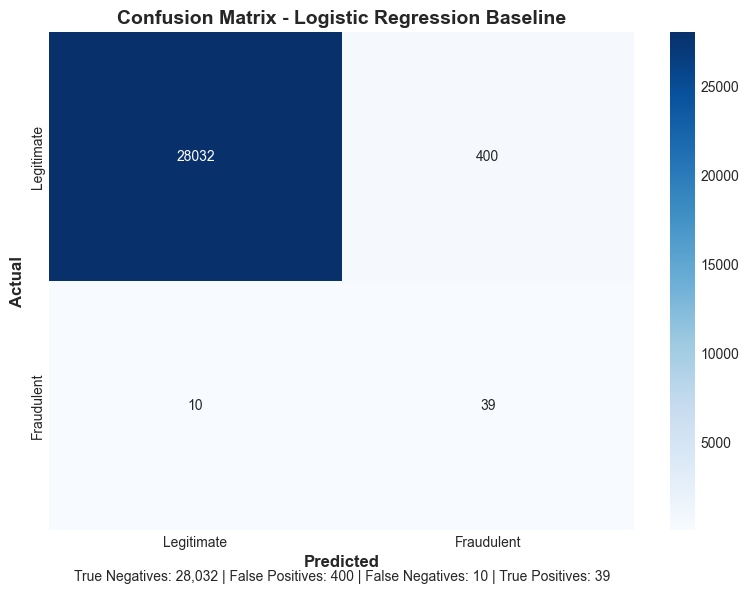


📊 Confusion Matrix Details:
   • True Negatives (Correct legit): 28,032
   • False Positives (Wrong fraud): 400
   • False Negatives (Missed fraud): 10
   • True Positives (Correct fraud): 39

💡 Business Metrics:
   • Fraud Detection Rate (Recall): 79.59%
   • False Alarm Rate: 1.4069%


In [4]:
# Cell 4: Confusion Matrix Analysis
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Logistic Regression Baseline', 
             fontsize=14, fontweight='bold')

# Add annotations
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.1, f'True Negatives: {tn:,} | False Positives: {fp:,} | False Negatives: {fn:,} | True Positives: {tp:,}',
        transform=ax.transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Confusion Matrix Details:")
print(f"   • True Negatives (Correct legit): {tn:,}")
print(f"   • False Positives (Wrong fraud): {fp:,}")
print(f"   • False Negatives (Missed fraud): {fn:,}")
print(f"   • True Positives (Correct fraud): {tp:,}")

# Calculate business metrics
fraud_catch_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"\n💡 Business Metrics:")
print(f"   • Fraud Detection Rate (Recall): {fraud_catch_rate:.2%}")
print(f"   • False Alarm Rate: {false_alarm_rate:.4%}")

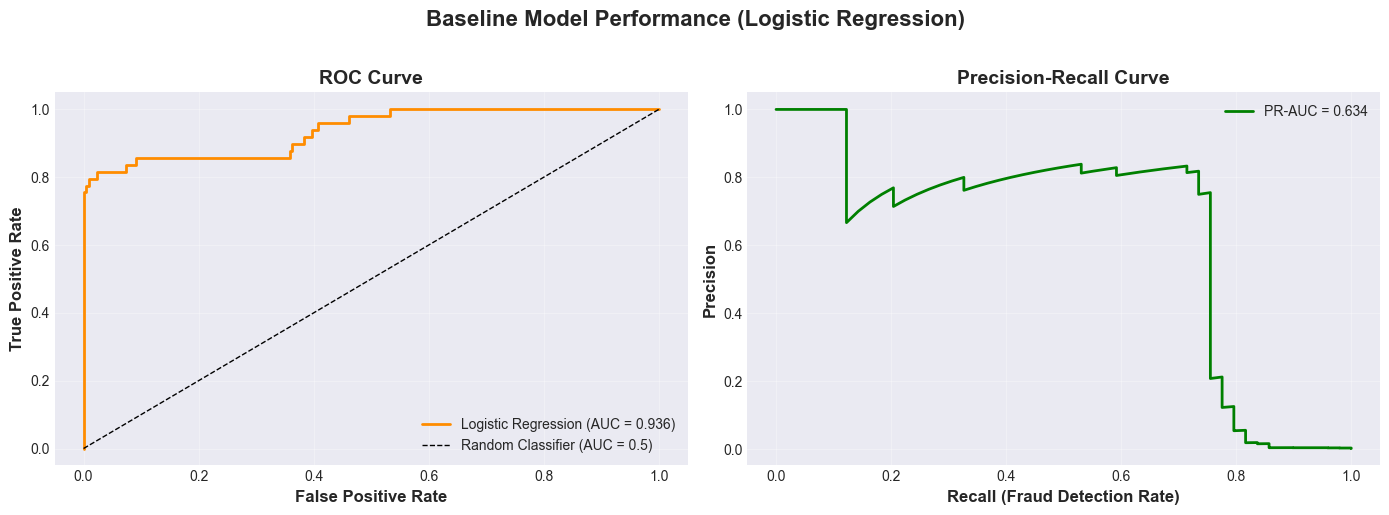

In [5]:
# Cell 5: ROC Curve and PR Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
axes[0].plot(fpr, tpr, linewidth=2, color='darkorange', label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR Curve
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_pred_proba)
axes[1].plot(recall, precision, linewidth=2, color='green', label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall (Fraud Detection Rate)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline Model Performance (Logistic Regression)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/baseline_performance_curves.png', dpi=150, bbox_inches='tight')
plt.show()

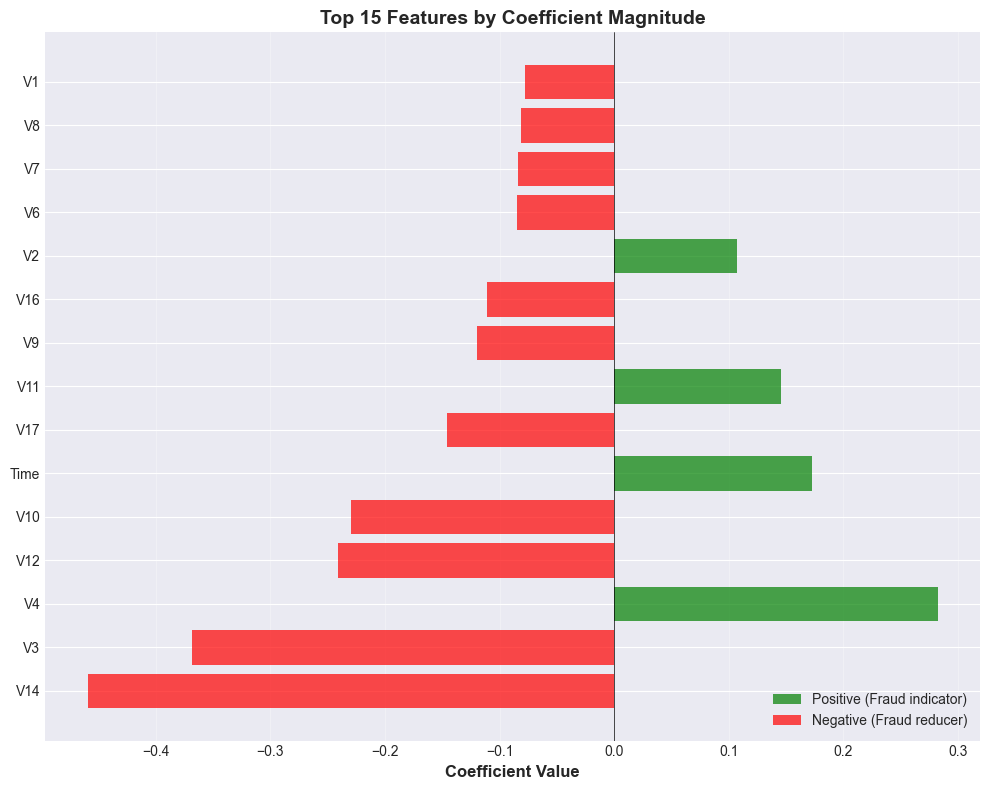


📈 Top 5 Features Increasing Fraud Risk:
   feature  coefficient
4       V4     0.282142
0     Time     0.172812
11     V11     0.145896
2       V2     0.106763
21     V21     0.047961

📉 Top 5 Features Decreasing Fraud Risk:
   feature  coefficient
14     V14    -0.459508
3       V3    -0.368904
12     V12    -0.240774
10     V10    -0.229777
17     V17    -0.146099


In [6]:
# Cell 6: Feature Importance (Coefficients)
# Get feature importance from coefficients
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': baseline_model.coef_[0]
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]

bars = ax.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features by Coefficient Magnitude', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='Positive (Fraud indicator)'),
                   Patch(facecolor='red', alpha=0.7, label='Negative (Fraud reducer)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../data/baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Top 5 Features Increasing Fraud Risk:")
print(feature_importance[feature_importance['coefficient'] > 0].head(5)[['feature', 'coefficient']])

print("\n📉 Top 5 Features Decreasing Fraud Risk:")
print(feature_importance[feature_importance['coefficient'] < 0].head(5)[['feature', 'coefficient']])

In [7]:
# Cell 7: Save the model
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(baseline_model, '../models/baseline_logistic_regression.pkl')
print("✅ Baseline model saved to: models/baseline_logistic_regression.pkl")

# Save metrics to JSON for later comparison
import json

baseline_metrics = {
    "model": "Logistic Regression",
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "accuracy": float(baseline_model.score(X_val, y_val)),
    "fraud_catch_rate": float(fraud_catch_rate),
    "false_alarm_rate": float(false_alarm_rate),
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp)
    }
}

with open('../models/baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)

print("✅ Metrics saved to: models/baseline_metrics.json")

✅ Baseline model saved to: models/baseline_logistic_regression.pkl
✅ Metrics saved to: models/baseline_metrics.json


In [8]:
# Cell 8: Test set evaluation (final check)
print("="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# Evaluate on test set
test_pred_proba = baseline_model.predict_proba(X_test)[:, 1]
test_pred = baseline_model.predict(X_test)

test_roc_auc = roc_auc_score(y_test, test_pred_proba)
test_pr_auc = average_precision_score(y_test, test_pred_proba)
test_accuracy = baseline_model.score(X_test, y_test)

print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\n✅ Baseline established! Ready for advanced models.")
print("\n💡 Next Steps:")
print("   • Train Random Forest (handles non-linear patterns)")
print("   • Train XGBoost (usually best for tabular data)")
print("   • Compare against baseline PR-AUC")

FINAL EVALUATION ON TEST SET
Test ROC-AUC: 0.9694
Test PR-AUC: 0.7169
Test Accuracy: 0.9847

✅ Baseline established! Ready for advanced models.

💡 Next Steps:
   • Train Random Forest (handles non-linear patterns)
   • Train XGBoost (usually best for tabular data)
   • Compare against baseline PR-AUC
